In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df_no159 = pd.read_excel('All-NO159-2.xlsx')
df_j4= pd.read_excel('All-J4ST2.xlsx')
df_j6a=pd.read_excel('All-J6A.xlsx')

In [3]:
df_j4= df_j4.iloc[:,[0,1,2]]


In [4]:
df_no159= df_no159.iloc[:,[0,1,2]]

In [6]:
df_j6a= df_j6a.iloc[:,[0,1,2]]



In [11]:
# Create a list of your dataframes and their names for easy iteration
wells = [
    (df_no159, "NO159-2"),
    (df_j4, "J4ST2"),
    (df_j6a, "J6A")
]

print(f"{'Well Name':<12} | {'Top (ft)':<10} | {'Bottom (ft)':<10} | {'Interval (ft)':<15} | {'Samples':<8}")
print("-" * 65)

for df, name in wells:
    # 1. Identify the Depth column (it's the first column)
    depth_col = df.columns[0]
    
    # 2. Extract Top and Bottom
    top_depth = df[depth_col].min()
    bottom_depth = df[depth_col].max()
    
    # 3. Calculate the physical Interval (Vertical thickness)
    interval = bottom_depth - top_depth
    
    # 4. Get the count of data points (Samples)
    num_samples = len(df)
    
    print(f"{name:<12} | {top_depth:<10.2f} | {bottom_depth:<10.2f} | {interval:<15.2f} | {num_samples:<8}")

Well Name    | Top (ft)   | Bottom (ft) | Interval (ft)   | Samples 
-----------------------------------------------------------------
NO159-2      | 5000.00    | 5150.00    | 150.00          | 150     
J4ST2        | 5000.00    | 5150.00    | 150.00          | 150     
J6A          | 5000.00    | 5150.00    | 150.00          | 150     


In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# --- 2. DTW ALGORITHM WITH SAKOE-CHIBA CONSTRAINT ---
def dtw_sakoe_chiba(s1, s2, window_percent=0.15):
    """
    Computes the DTW distance between two standardized log sequences.
    window_percent: The width of the Sakoe-Chiba constraint band.
    """
    n, m = len(s1), len(s2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Calculate window size and ensure it covers the difference in log lengths
    window = int(window_percent * max(n, m))
    window = max(window, abs(n - m))

    for i in range(1, n + 1):
        # Calculate within the Sakoe-Chiba band
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            # Cost is the absolute difference between standardised values
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j],    # insertion
                                          dtw_matrix[i, j-1],    # deletion
                                          dtw_matrix[i-1, j-1])  # match
    return dtw_matrix[n, m]

# --- 3. STANDARDIZATION (Z-Score) ---
scaler = StandardScaler()


In [15]:
# Standardize the NPHI for your 3 existing dataframes
nphi_no159 = scaler.fit_transform(df_no159[['Neutron Porosity']].values).flatten()
nphi_j6a = scaler.fit_transform(df_j6a[['Neutron Porosity']].values).flatten()
nphi_j4 = scaler.fit_transform(df_j4[['Neutron Porosity']].values).flatten()
# converting gr values such that MEAN =0 STD DEV =1

# Calculate NPHI Distances for all combinations
dist_nphi_no_j6 = dtw_sakoe_chiba(nphi_no159, nphi_j6a, int(0.15 * max(len(nphi_no159), len(nphi_j6a))))
dist_nphi_j6_j4 = dtw_sakoe_chiba(nphi_j6a, nphi_j4, int(0.15 * max(len(nphi_j6a), len(nphi_j4))))
dist_nphi_j4_no = dtw_sakoe_chiba(nphi_j4, nphi_no159, int(0.15 * max(len(nphi_j4), len(nphi_no159))))

print(f"NPHI Distance NO159-J6A: {dist_nphi_no_j6:.2f}")
print(f"NPHI Distance J6A-J4: {dist_nphi_j6_j4:.2f}")
print(f"NPHI Distance J4-NO159: {dist_nphi_j4_no:.2f}")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Standardize the GR for your 3 existing dataframes
gr_no159 = scaler.fit_transform(df_no159[['GR (API)']].values).flatten()
gr_j6a = scaler.fit_transform(df_j6a[['GR (API)']].values).flatten()
gr_j4 = scaler.fit_transform(df_j4[['GR (API)']].values).flatten()

# Calculate GR Distances for all combinations
# NO159-2 to J6A
dist_gr_no_j6 = dtw_sakoe_chiba(gr_no159, gr_j6a, int(0.15 * max(len(gr_no159), len(gr_j6a))))

# J6A to J4
dist_gr_j6_j4 = dtw_sakoe_chiba(gr_j6a, gr_j4, int(0.15 * max(len(gr_j6a), len(gr_j4))))

# J4 to NO159-2
dist_gr_j4_no = dtw_sakoe_chiba(gr_j4, gr_no159, int(0.15 * max(len(gr_j4), len(gr_no159))))

print(f"GR Distance NO159-J6A: {dist_gr_no_j6:.2f}")
print(f"GR Distance J6A-J4: {dist_gr_j6_j4:.2f}")
print(f"GR Distance J4-NO159: {dist_gr_j4_no:.2f}")

NPHI Distance NO159-J6A: 84.51
NPHI Distance J6A-J4: 76.75
NPHI Distance J4-NO159: 76.97
GR Distance NO159-J6A: 86.85
GR Distance J6A-J4: 89.90
GR Distance J4-NO159: 83.42


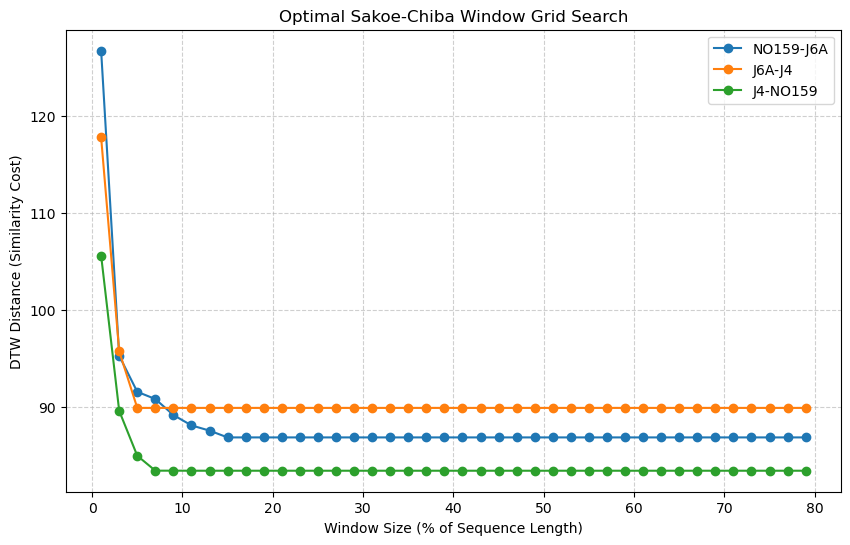

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Define DTW with Sakoe-Chiba
def dtw_sakoe_chiba(s1, s2, window):
    n, m = len(s1), len(s2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    # Window must be at least the difference in lengths
    window = max(window, abs(n - m))
    for i in range(1, n + 1):
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], dtw_matrix[i, j-1], dtw_matrix[i-1, j-1])
    return dtw_matrix[n, m]

# 2. Standardize GR Logs (Assuming your df_no159, df_j6a, df_j4 are ready)
scaler = StandardScaler()
gr_no159 = scaler.fit_transform(df_no159[['GR (API)']].values).flatten()
gr_j6a = scaler.fit_transform(df_j6a[['GR (API)']].values).flatten()
gr_j4 = scaler.fit_transform(df_j4[['GR (API)']].values).flatten()

# 3. Perform Grid Search (1% to 60%)
window_percents = np.arange(1, 80, 2)
combos = [(gr_no159, gr_j6a, "NO159-J6A"), (gr_j6a, gr_j4, "J6A-J4"), (gr_j4, gr_no159, "J4-NO159")]
all_results = {}

for s1, s2, label in combos:
    distances = []
    for p in window_percents:
        w = int((p/100.0) * max(len(s1), len(s2)))
        dist = dtw_sakoe_chiba(s1, s2, w)
        distances.append(dist)
    all_results[label] = distances

#4. Plot the Elbow Curves
plt.figure(figsize=(10, 6))
for label, distances in all_results.items():
    plt.plot(window_percents, distances, marker='o', label=label)

plt.title('Optimal Sakoe-Chiba Window Grid Search')
plt.xlabel('Window Size (% of Sequence Length)')
plt.ylabel('DTW Distance (Similarity Cost)')
plt.savefig('GR_Sakoe.png', dpi=300, bbox_inches='tight')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()





In [19]:
# Create a small function to find the first percentage that hits the 'floor'
def get_best_window(percent_list, distance_list):
    # Find the minimum distance achieved
    min_dist = min(distance_list)
    # Find the index of the first time that minimum was reached
    best_index = distance_list.index(min_dist)
    # Return the corresponding percentage
    return percent_list[best_index]

# Use the variables from your previous grid search loop
best_no_j6 = get_best_window(window_percents.tolist(), all_results["NO159-J6A"])
best_j6_j4 = get_best_window(window_percents.tolist(), all_results["J6A-J4"])
best_j4_no = get_best_window(window_percents.tolist(), all_results["J4-NO159"])

print(f"Optimal Window for NO159-J6A: {best_no_j6}%")
print(f"Optimal Window for J6A-J4: {best_j6_j4}%")
print(f"Optimal Window for J4-NO159: {best_j4_no}%")

Optimal Window for NO159-J6A: 15%
Optimal Window for J6A-J4: 5%
Optimal Window for J4-NO159: 11%


--- Optimized NPHI Windows ---
NO159-J6A: 7%
J6A-J4:    17%
J4-NO159:  11%


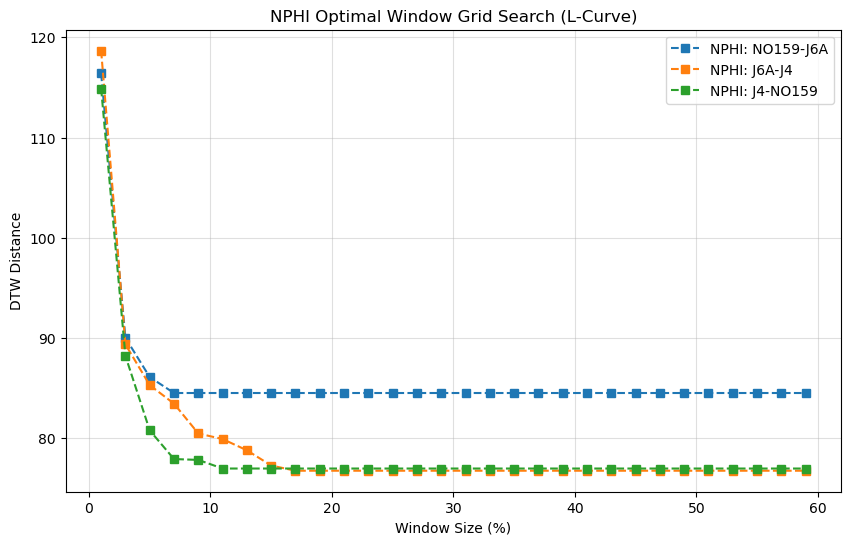

In [21]:
# 1. Define the range for NPHI Grid Search
window_percents = np.arange(1, 61, 2)
nphi_combos = [
    (nphi_no159, nphi_j6a, "NO159-J6A"), 
    (nphi_j6a, nphi_j4, "J6A-J4"), 
    (nphi_j4, nphi_no159, "J4-NO159")
]

nphi_grid_results = {}

# 2. Execute Grid Search for NPHI
for s1, s2, label in nphi_combos:
    distances = []
    for p in window_percents:
        w = int((p/100.0) * max(len(s1), len(s2)))
        dist = dtw_sakoe_chiba(s1, s2, w)
        distances.append(dist)
    nphi_grid_results[label] = distances

# 3. Plot NPHI L-Curves
plt.figure(figsize=(10, 6))
for label, distances in nphi_grid_results.items():
    plt.plot(window_percents, distances, marker='s', linestyle='--', label=f"NPHI: {label}")

plt.title('NPHI Optimal Window Grid Search (L-Curve)')
plt.xlabel('Window Size (%)')
plt.ylabel('DTW Distance')
plt.grid(True, alpha=0.4)
plt.legend()
#plt.show()

# 4. Function to identify the 'Elbow' (First point of stability)
def find_nphi_best_window(p_list, d_list):
    # Find the absolute minimum distance
    min_d = min(d_list)
    # Find the first index where the distance is within 0.5% of the minimum
    for i, d in enumerate(d_list):
        if (d - min_d) / min_d < 0.005:
            return p_list[i]
    return p_list[-1]

# 5. Output the Best Windows for NPHI
best_nphi_no_j6 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["NO159-J6A"])
best_nphi_j6_j4 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["J6A-J4"])
best_nphi_j4_no = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["J4-NO159"])

print(f"--- Optimized NPHI Windows ---")
print(f"NO159-J6A: {best_nphi_no_j6}%")
print(f"J6A-J4:    {best_nphi_j6_j4}%")
print(f"J4-NO159:  {best_nphi_j4_no}%")

## J6A-J4ST2

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Publication-ready styling (Standardized for all plots)
# 1. MATCHING GLOBAL STYLE
plt.rcParams.update({
    "font.family": "serif",
    "font.weight": "normal",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.labelsize": 30,
    "axes.titlesize": 34,
    "legend.fontsize": 30,
    "figure.figsize": (18, 18),
    "axes.linewidth": 2.0
})
def find_elbow(p_list, d_list):
    min_d = min(d_list)
    for i, d in enumerate(d_list):
        if (d - min_d) / (min_d if min_d != 0 else 1) < 0.005:
            return p_list[i], d_list[i]
    return p_list[-1], d_list[-1]

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import os
'''
def plot_well_optimization(percents, distances, well_pair, log_type):
    # Ensure directory exists
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    
    # 1. Convert to lists to find the index of the 'elbow'
    percents_list = list(percents)
    dist_list = list(distances)
    min_dist = min(dist_list)
    opt_idx = dist_list.index(min_dist)
    opt_window = percents_list[opt_idx]
    
    # 2. Setup Figure
    fig, ax = plt.subplots()   # rcParams already controls size    
    # 3. Plot Data & Stability Shading
    ax.plot(percents_list, dist_list, marker='o', ms=12, 
            lw=5, color='#1f77b4', label='DTW Cost (GR)')
    
    ax.axvspan(opt_window, max(percents_list), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # 4. Mark Optimum Point (Red Star)
   
    ax.scatter(opt_window, min_dist, color='red', edgecolor='black', s=400, marker='*', zorder=10)

    # 5. Annotation with Dynamic Positioning
    ax.annotate(f'Optimum Window: {opt_window}%',
                xy=(opt_window, min_dist),
                xytext=(opt_window + 10, min_dist +5),
                fontsize=30, fontweight='bold',
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", lw=2),
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1.5))

    # 6. Formatting & Consistency
    ax.set_title(f"Optimization: {well_pair} ({log_type})", pad=30)
    ax.set_xlabel("Sakoe-Chiba Window Size (% of Sequence Length)", labelpad=15)
    ax.set_ylabel("DTW Distance (Similarity Cost)", labelpad=15)
    ax.grid(True, linestyle='--', alpha=0.6)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')    # Legend locked to Top Right
    ax.legend(fontsize=30, loc='upper right', frameon=True, shadow=True)
    
    plt.tight_layout()
    plt.savefig(f"L_curve/{well_pair}_{log_type}_warp.jpg", dpi=300)
    plt.show()
'''
# Define the ranges used during your grid search
gr_range = np.arange(1, 80, 2)
nphi_range = np.arange(1, 61, 2)

## for correlation plot 

In [34]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Zone definitions from your provided data
zones_j6a= {
    'Asl Marl': (5000, 5045, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5045, 5095, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5095, 5130, '#d9ead3')   # Light Green
}

zones_j4= {
    'Asl Marl': (5000, 5050, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5050, 5100, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5100, 5130, '#d9ead3')   # Light Green
}

# We'll assume J6A follows a similar stratigraphic sequence 
# based on your window search results.

In [26]:
def plot_correlation(df1, df2, label1, label2, window_p):
    fig, axes = plt.subplots(1, 2, figsize=(10, 12), sharey=False)
    
    # Calculate warping path using your dtw_sakoe_chiba logic
    # (Extract the path indices i, j from your DTW matrix)
    # path = get_dtw_path(s1, s2, window_p) 

    for ax, df, zones, name in zip(axes, [df1, df2], [zones_no159, zones_j4], [label1, label2]):
        depth = df.iloc[:, 0]
        gr = df.iloc[:, 1]
        
        # Plot GR Log
        ax.plot(gr, depth, color='black', lw=0.7)
        ax.set_title(name)
        ax.invert_yaxis()
        
        # Color the Zones
        for zone, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, color=color, alpha=0.5, label=zone)
            # Add text label for lithology
            ax.text(ax.get_xlim()[1], (top+bottom)/2, zone, verticalalignment='center')

    # Draw Correlation Lines (Connect points using the DTW path)
    # This visually shows how the "Thick Beds" match despite depth shifts
    plt.tight_layout()
    plt.show()

# Example call using your optimized 37% window for NO159-J6A
# plot_correlation(df_no159, df_j6a, "NO159-2", "J6A", 0.37)

In [36]:
def dtw_with_path(s1, s2, window_p):
    n, m = len(s1), len(s2)
    window = max(int(window_p * max(n, m)), abs(n - m))
    
    # Initialize cost matrix
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Fill matrix
    for i in range(1, n + 1):
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])
    
    # Backtrack to find the path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        # Find the minimum neighbor to step back to
        prev_steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        best_step = np.argmin(prev_steps)
        if best_step == 0: i, j = i-1, j-1
        elif best_step == 1: i -= 1
        else: j -= 1
    
    return path[::-1] # Return path from beginning to end

## final plots 

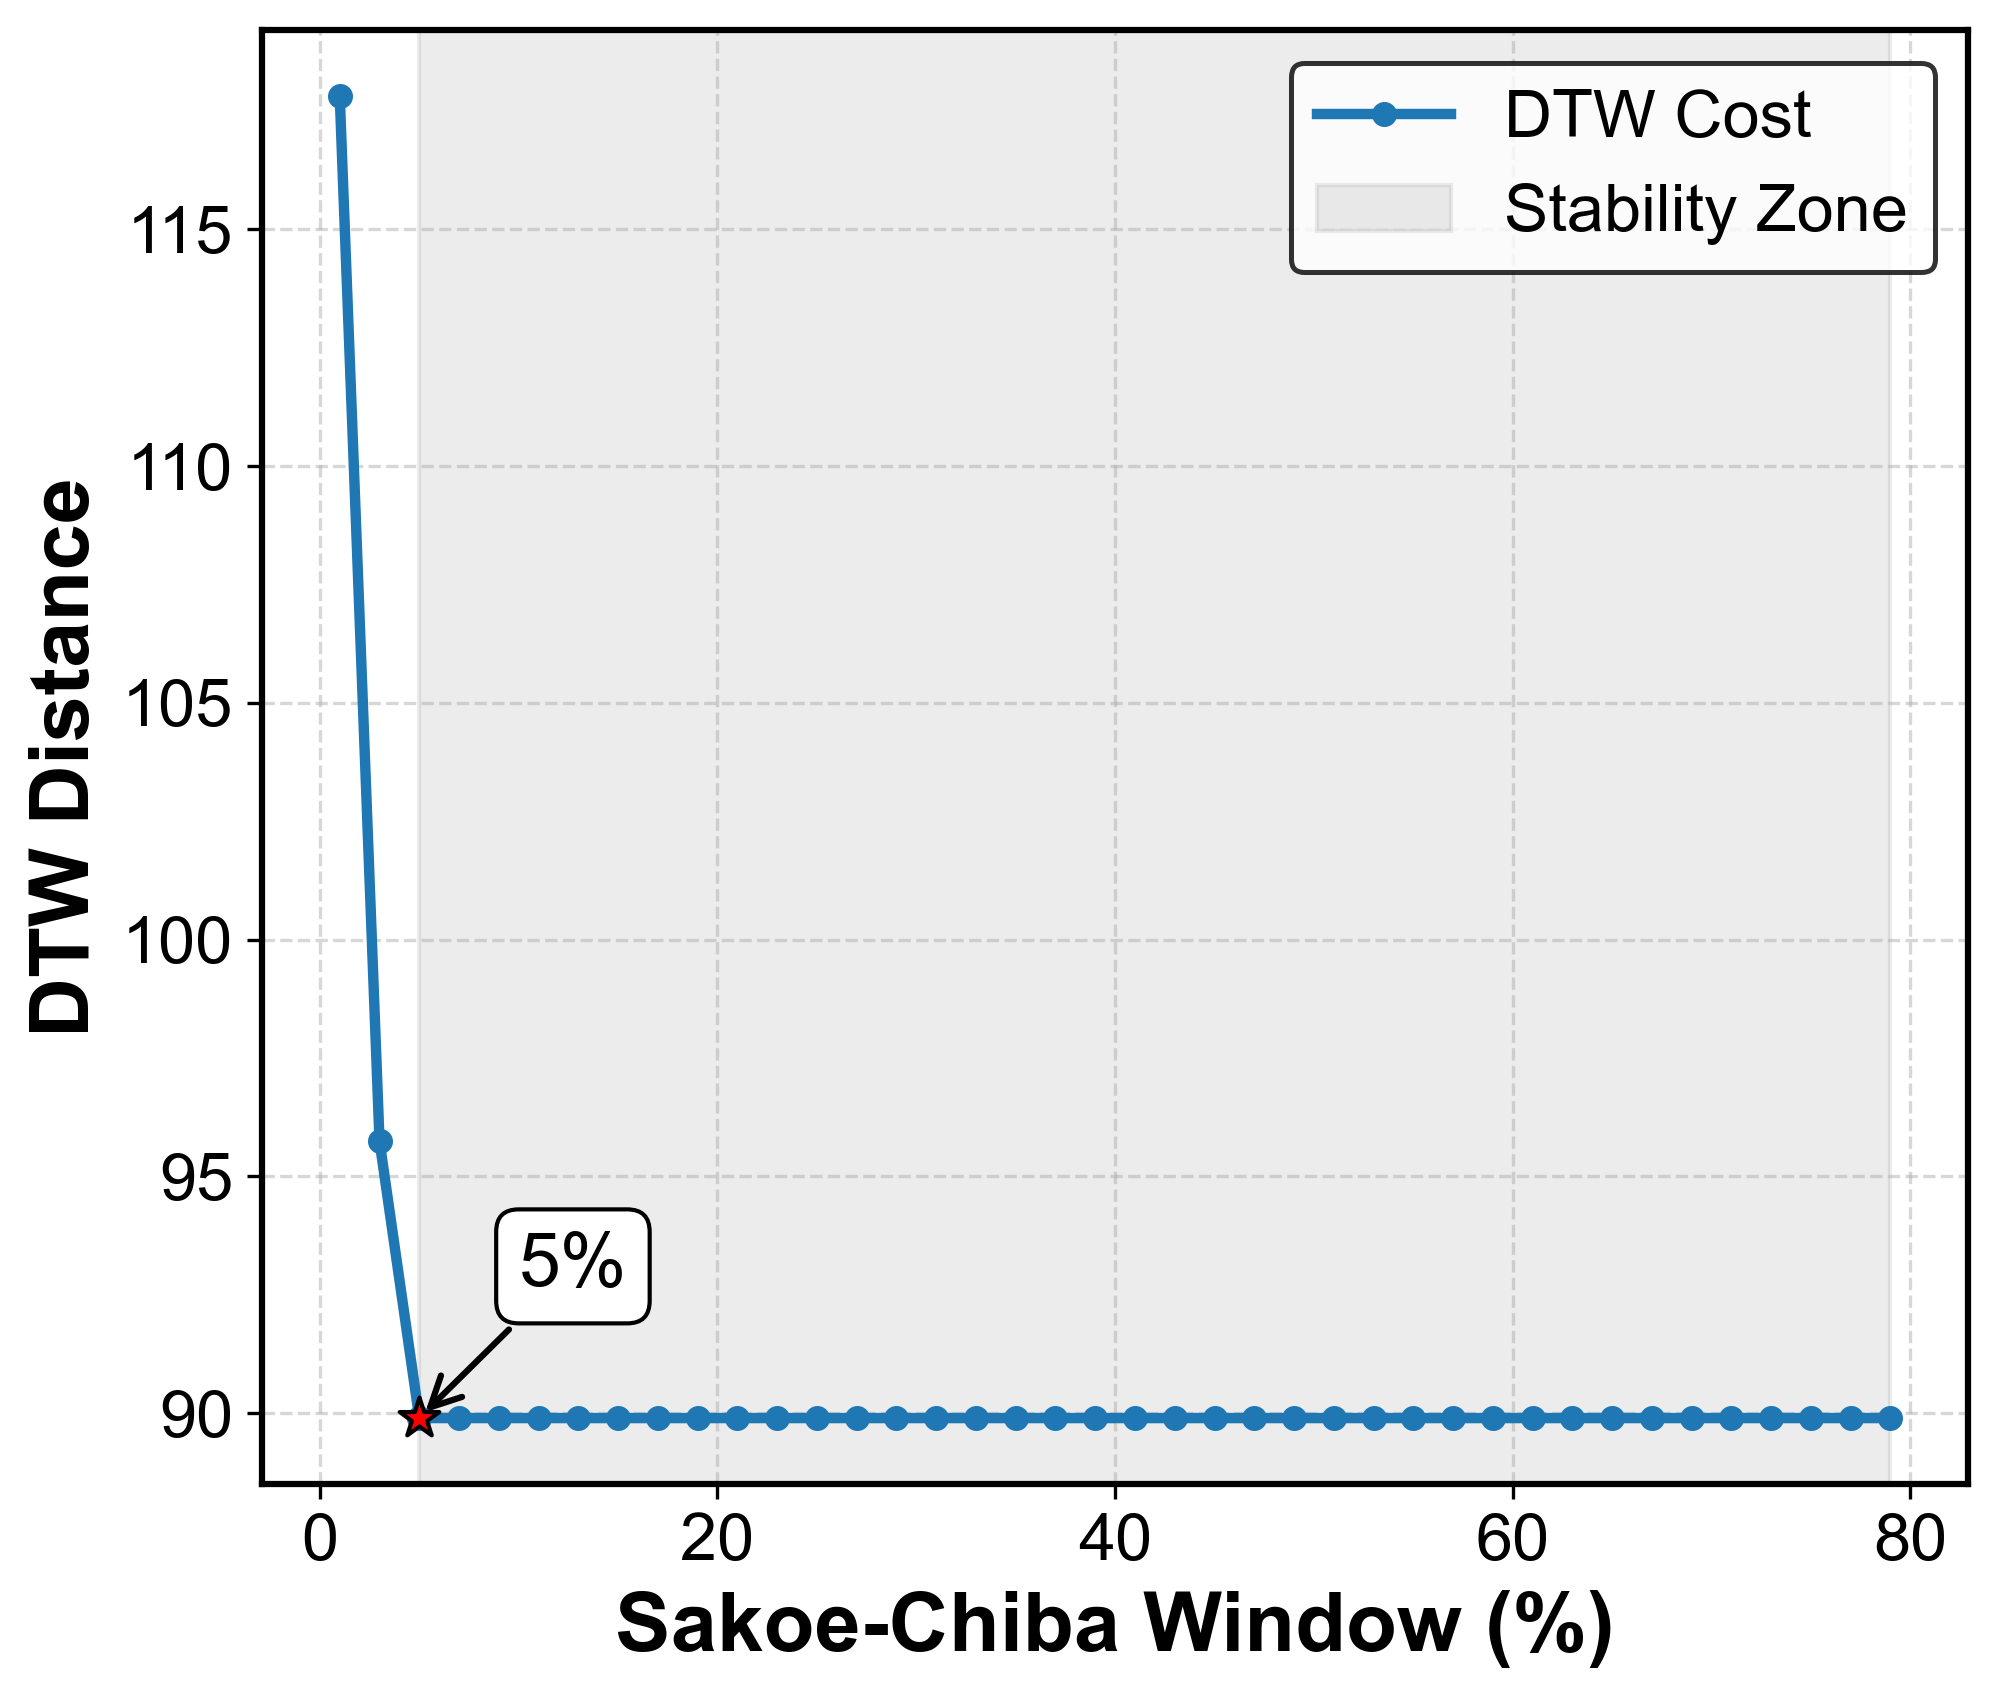

Plot saved to: L_curve/J6A-J4_Gamma Ray_Lcurve_FINAL.jpg


In [46]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Apply the global font/style settings from your first example
plt.rcParams.update({
    "font.family": "Arial",  # Matches the serif look of the first plot
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_well_optimization(percents, distances, well_pair, log_type):
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    
    percents_list = list(percents)
    dist_list = list(distances)
    min_dist = min(dist_list)
    opt_idx = dist_list.index(min_dist)
    opt_window = percents_list[opt_idx]
    
    # 1. Matching Figure Size (7x6 from first plot)
    fig, ax = plt.subplots(figsize=(7, 6))

    # 2. Matching Line & Marker Style (lw=2.5, ms=5)
    ax.plot(percents_list, dist_list, color='#1f77b4', lw=2.5, 
            marker='o', ms=5, label='DTW Cost')
    
    # 3. Stability Zone
    ax.axvspan(opt_window, max(percents_list), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # 4. Optimal point (Scaled down to s=100)
    ax.scatter(opt_window, min_dist, color='red', edgecolor='black', 
               s=100, marker='*', zorder=10)

    # 5. Annotation (Clean style, no massive fonts)
    ax.annotate(f'{opt_window}%',
                xy=(opt_window, min_dist),
                xytext=(opt_window + 5, min_dist + (max(dist_list)-min_dist)*0.1),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

    # 6. Spine/Border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    # 7. Labels (Simplified as per first plot)
    ax.set_xlabel("Sakoe-Chiba Window (%)")
    ax.set_ylabel("DTW Distance")

    # 8. Legend (Visible, Clean, No Shadow)
    leg = ax.legend(loc='upper right', frameon=True)
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(1.2)

    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    save_path = f"L_curve/{well_pair}_{log_type}_Lcurve_FINAL.jpg"
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.02)
    plt.show()
    print(f"Plot saved to: {save_path}")

# CALL
gr_range = np.arange(1, 80, 2)
# Ensure all_results contains your J6A-J4 data
plot_well_optimization(gr_range, all_results["J6A-J4"], "J6A-J4", "Gamma Ray")

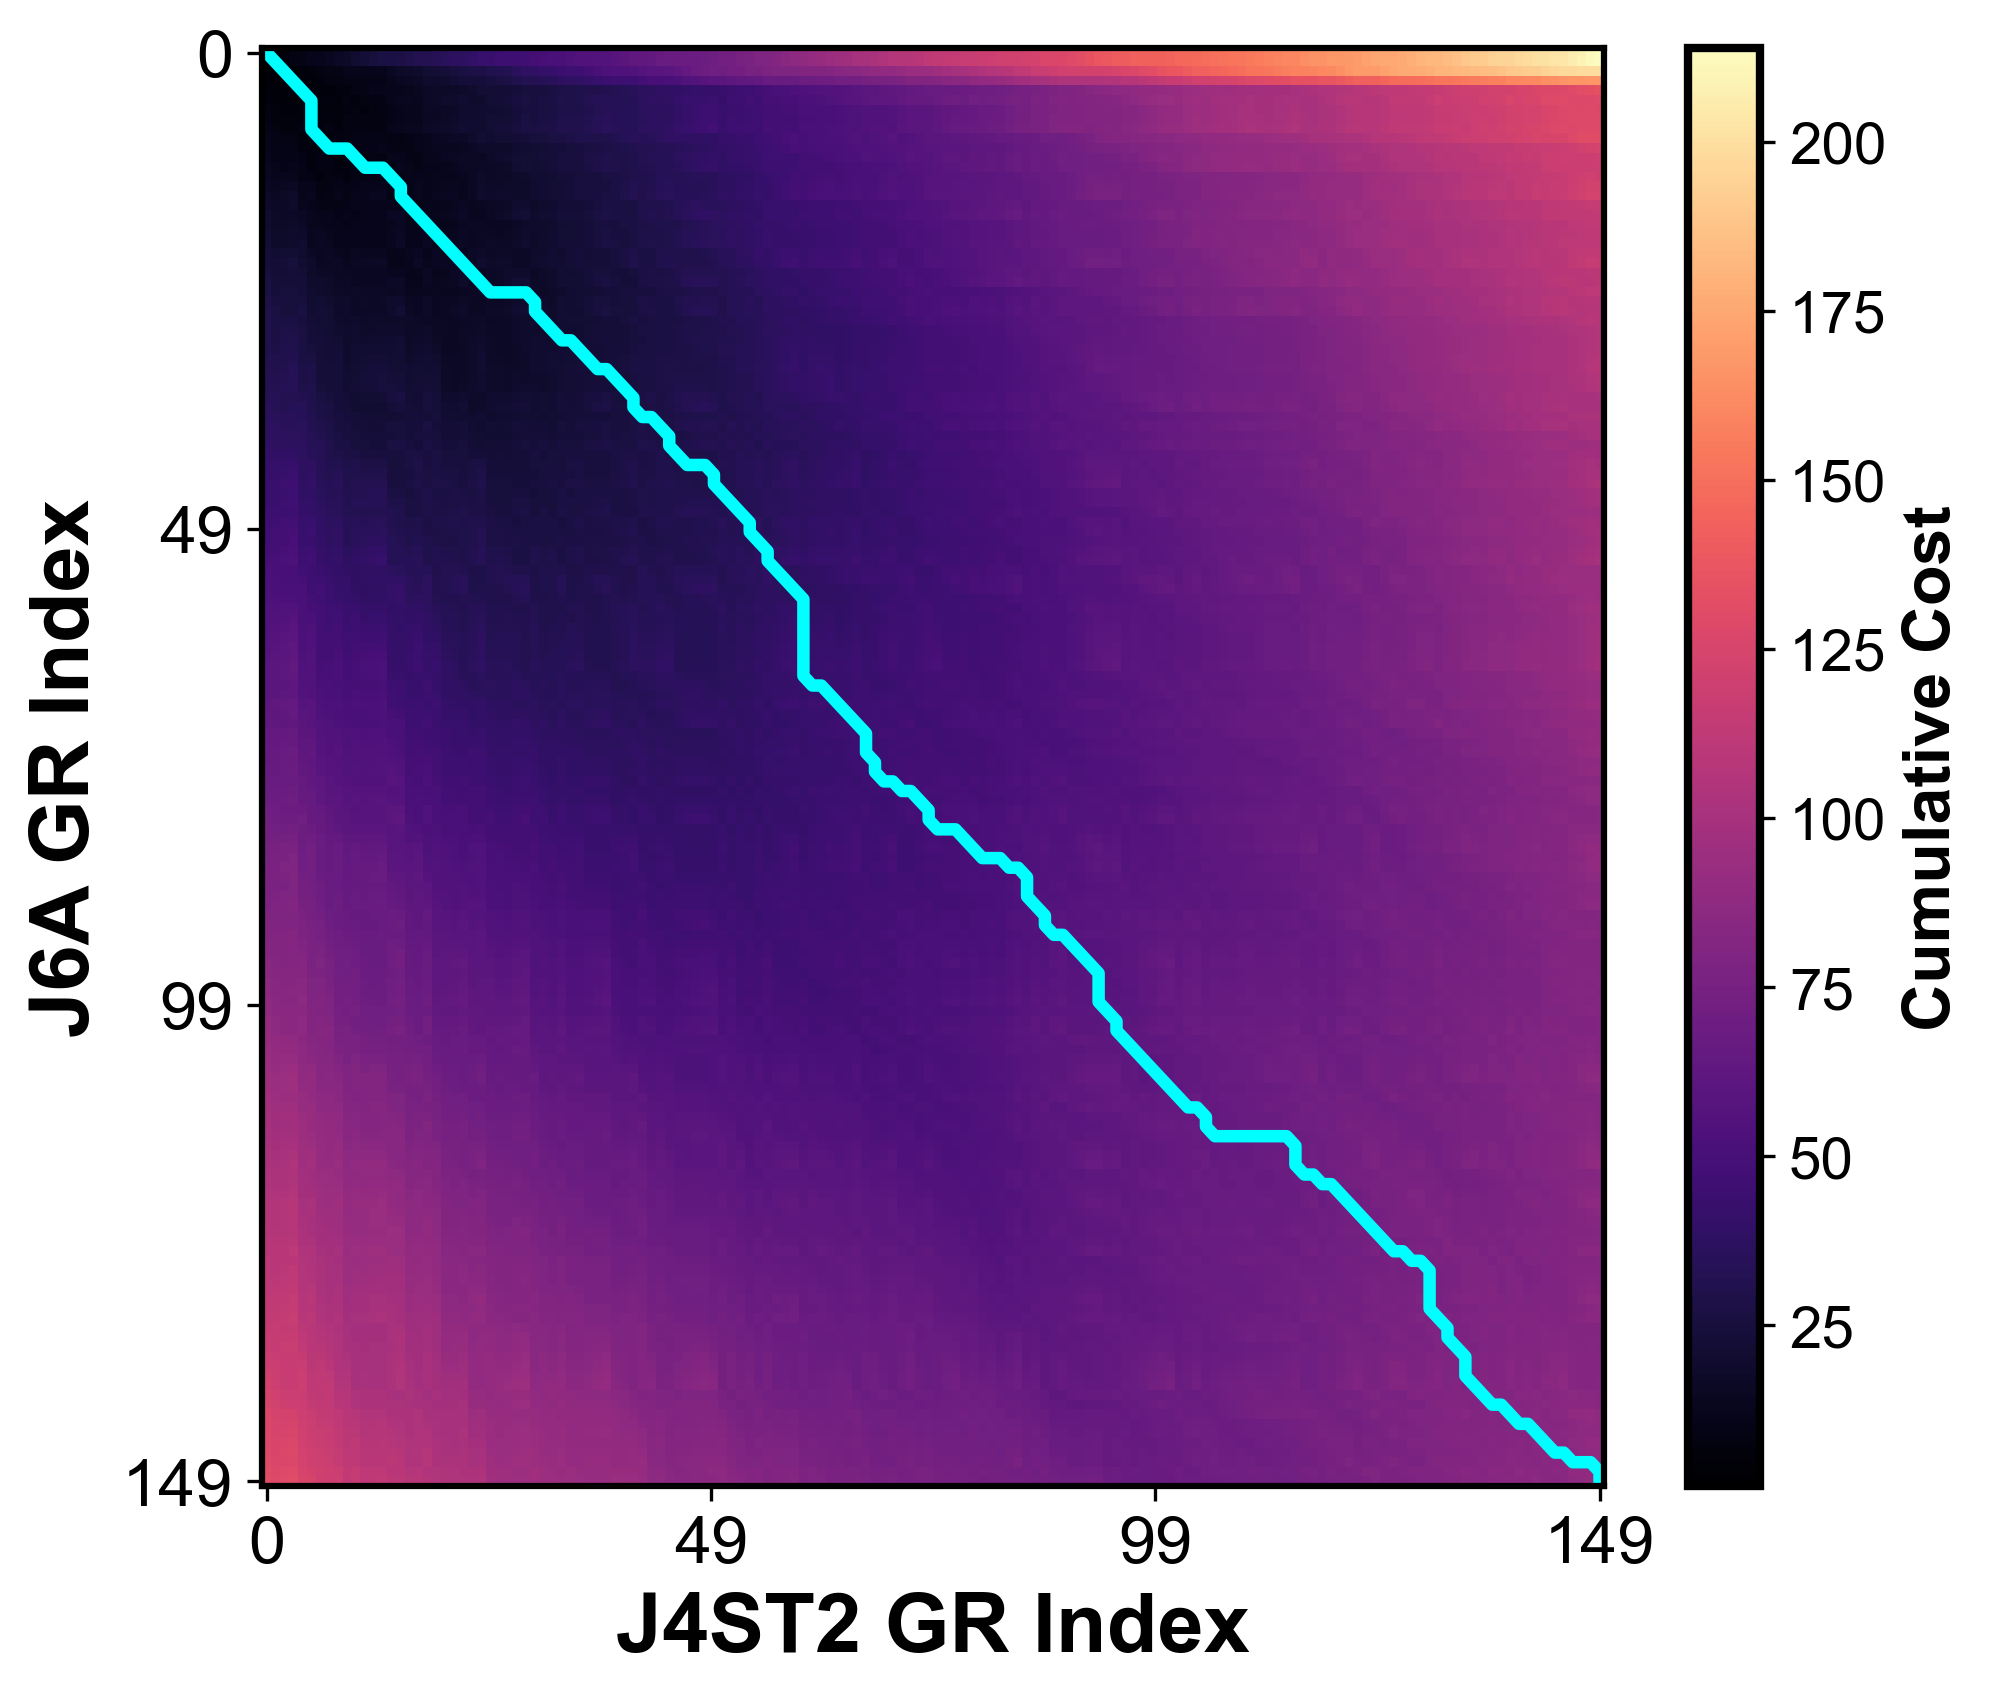

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# --- STYLE PARAMETERS (Matching Publication Quality) ---
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_full_warping_path_J4_J6(df1, df2, label1="J4ST2", label2="J6A"):
    # 1. Standardize the logs
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 1].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 1].values.reshape(-1,1)).flatten()
    n, m = len(s1), len(s2)
    
    # 2. Compute FULL DTW matrix (No Window)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):  # Full range iteration
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],
                dtw_matrix[i, j-1],
                dtw_matrix[i-1, j-1]
            )
    
    # 3. Backtracking
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        move = np.argmin(steps)
        if move == 0: i, j = i-1, j-1
        elif move == 1: i -= 1
        else: j -= 1
    path = np.array(path[::-1])

    # 4. VISUALIZATION (7x6 Figure)
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # Slice matrix to remove the padding row/column
    full_matrix = dtw_matrix[1:, 1:]
    
    img = ax.imshow(
        full_matrix.T,
        origin='upper',
        cmap='magma',
        aspect='auto'
    )
    
    # 5. PLOT PATH (Cyan, Thick)
    ax.plot(path[:, 0], path[:, 1], color='cyan', linewidth=3, label='Optimal Path')
    
    # 6. LABELS & TICKS (Matching Style)
    ax.set_xlabel(f"{label1} GR Index")
    ax.set_ylabel(f"{label2} GR Index")
    
    # Set 4 clean ticks for X and Y
    xticks = np.linspace(0, n-1, 4)
    yticks = np.linspace(0, m-1, 4)
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in xticks])
    ax.set_yticks(yticks)
    ax.set_yticklabels([int(y) for y in yticks])

    # 7. COLORBAR
    cbar = plt.colorbar(img)
    cbar.set_label("Cumulative Cost", fontsize=16, fontweight='bold')
    cbar.ax.tick_params(labelsize=14)

    # Borders & Cleanup
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')
    
    ax.grid(False)
    plt.tight_layout()

    # Save
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_full_warping_FINAL.jpg"
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

# EXECUTE
plot_full_warping_path_J4_J6(df_j4, df_j6a)

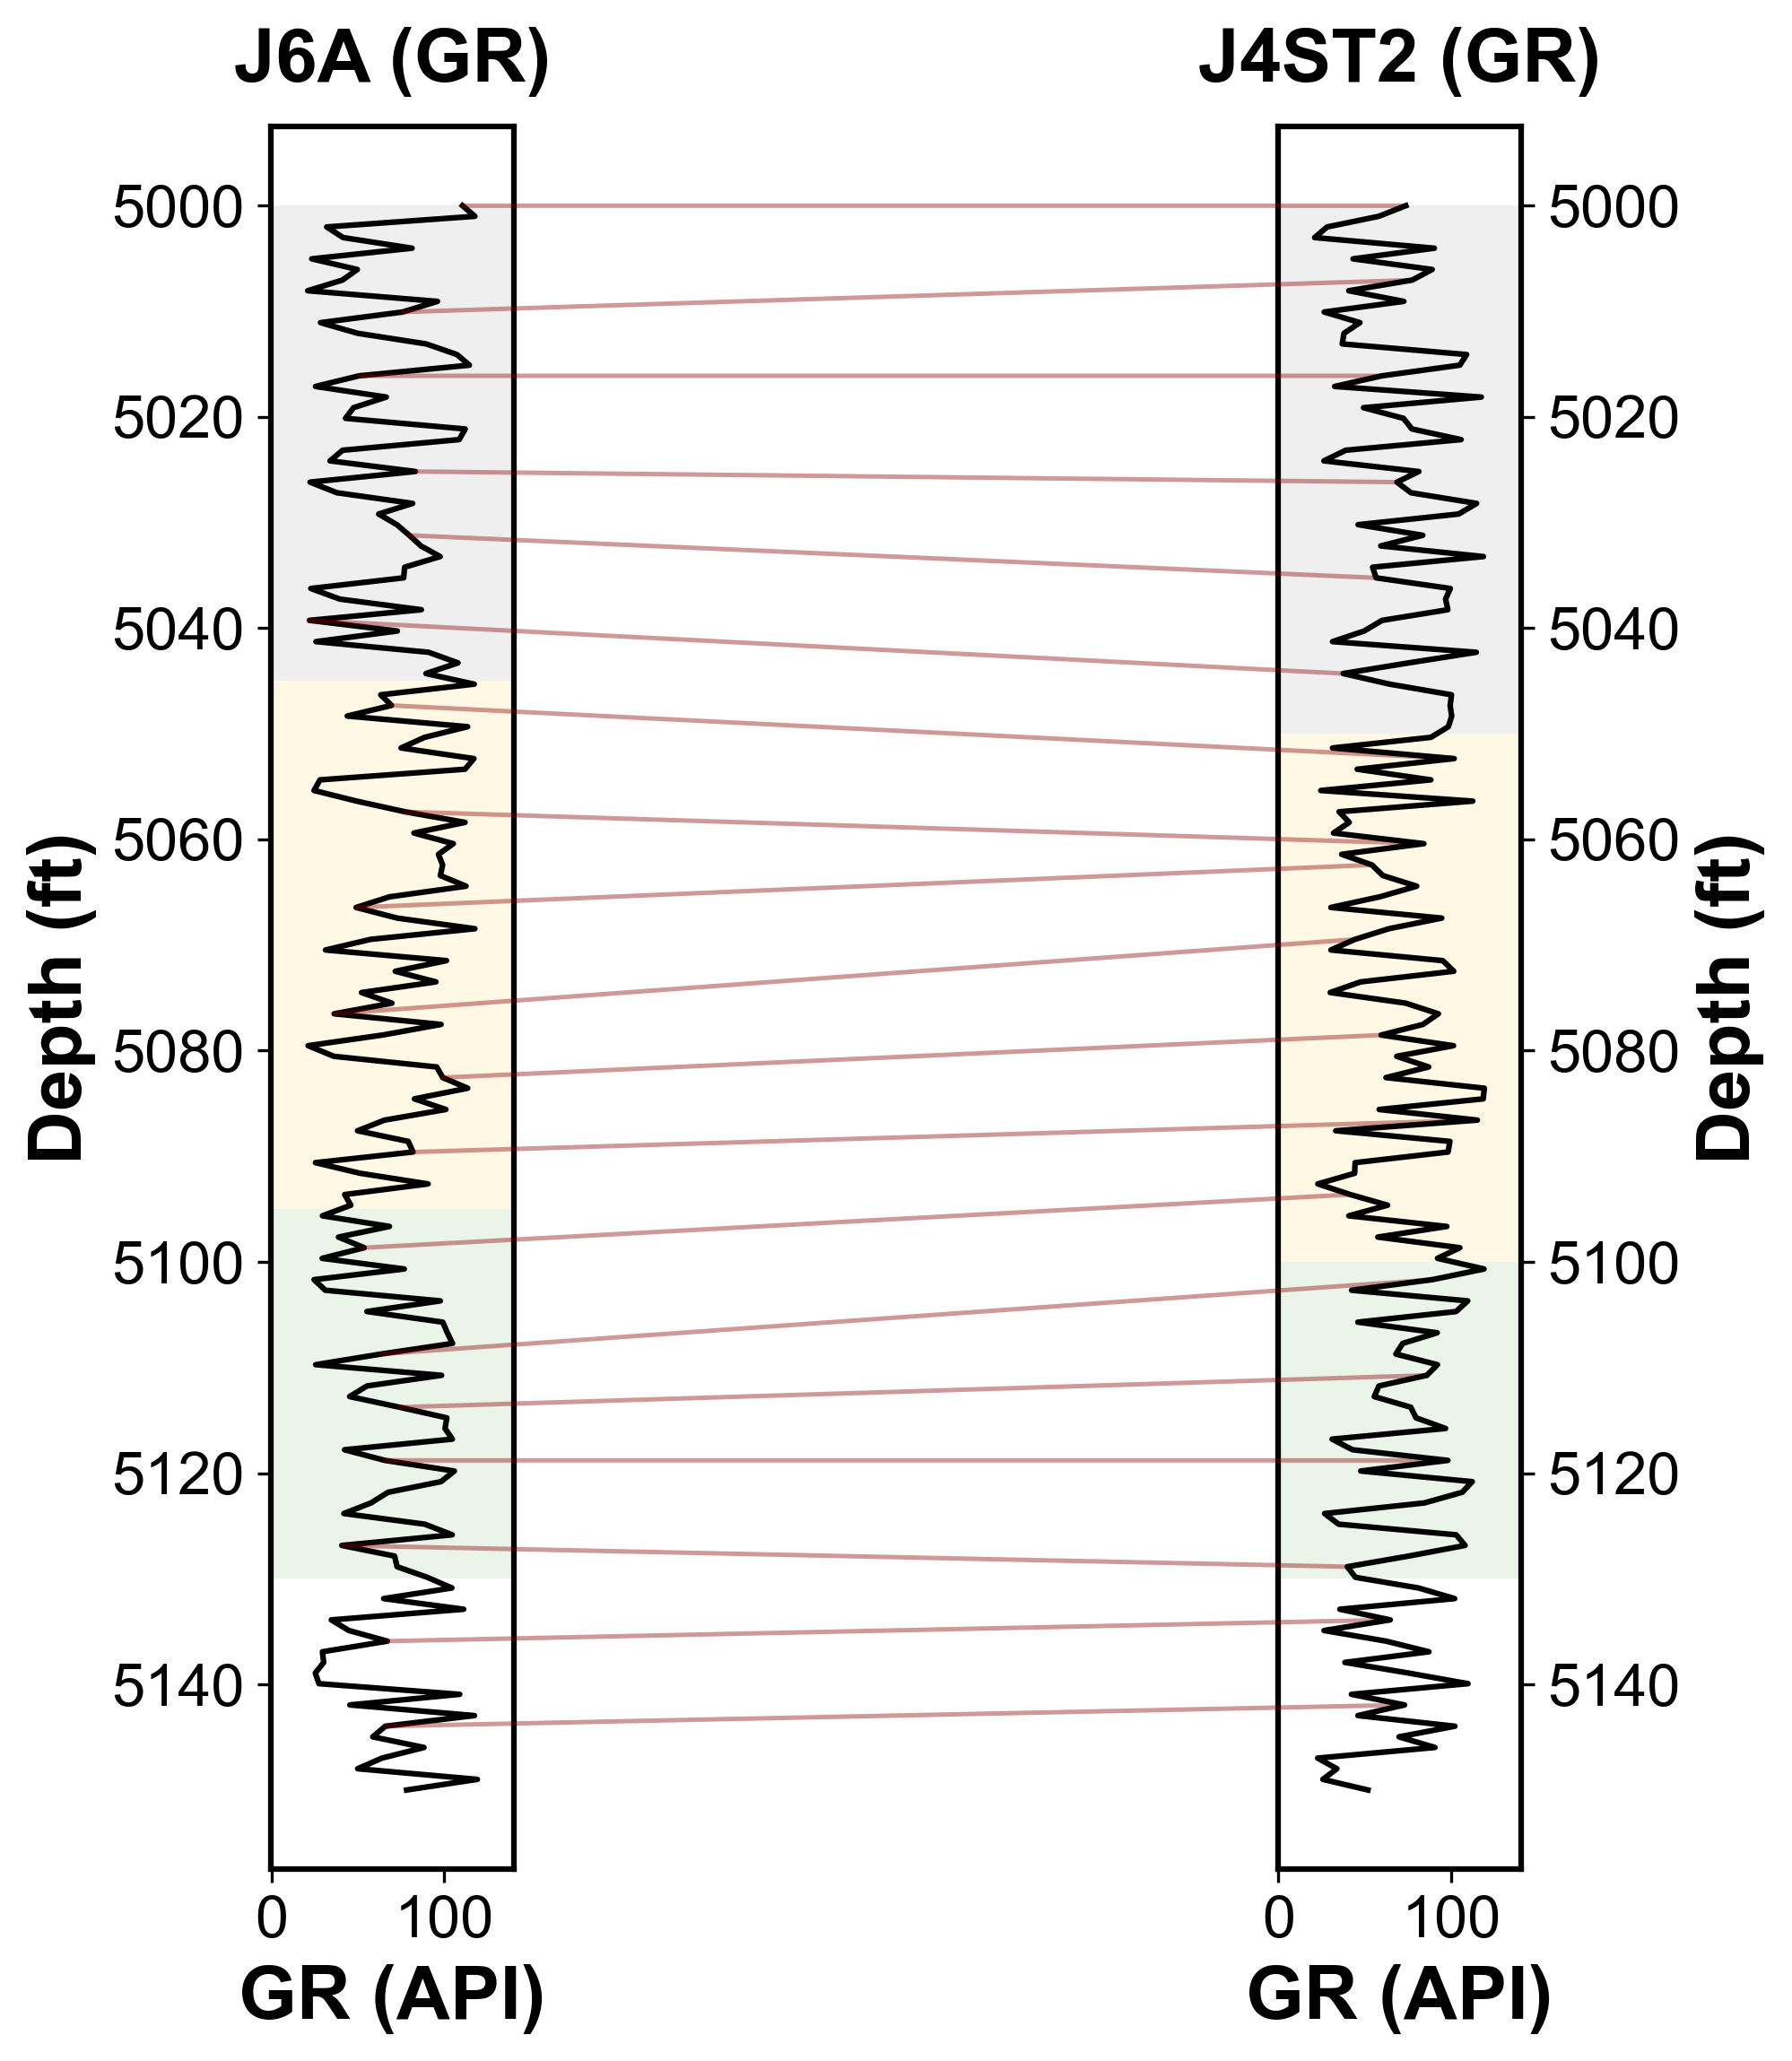

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import StandardScaler
import os

# --- STYLE FOR PUBLICATION (Matches Plot 1) ---
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_gr_correlation_j6_j4_no_grid(df1, df2, zones1, zones2, label1, label2, window_p):
    # 1. Standardize GR logs
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 1].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 1].values.reshape(-1,1)).flatten()
    
    # 2. Get the path
    path = dtw_with_path(s1, s2, window_p)
    
    # 3. Figure Setup (Matching the 7x8 aspect of Plot 1)
    fig, axes = plt.subplots(1, 2, figsize=(7, 8)) 

    for i, (df, zones, name) in enumerate([(df1, zones1, label1), (df2, zones2, label2)]):
        ax = axes[i]
        depth = df.iloc[:, 0]
        gr = df.iloc[:, 1]
        
        # Plot Log (lw=1.5)
        ax.plot(gr, depth, color='black', lw=1.5, zorder=5)
        ax.invert_yaxis()
        
        # Labels and Titles
        ax.set_title(f"{name} (GR)", fontweight='bold', pad=12)
        ax.set_xlabel("GR (API)")
        ax.set_ylabel("Depth (ft)")

        if i == 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()
        
        # 4. Stratigraphic Shading (FIXED: Using facecolor to remove warnings)
        for _, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, facecolor=color, alpha=0.5, zorder=2)

        # 5. X-AXIS PADDING
        xmin, xmax = ax.get_xlim()
        pad = 0.15 * (xmax - xmin)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Border styling
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')

        # GRID REMOVED
        ax.grid(False)

    # 6. Correlation Lines (lw=1.2 and alpha=0.4)
    # --- FIX 2: Reduced step size from 120 to 10 for validation datasets ---
    line_density_step = 10 

    for idx in range(0, len(path), line_density_step): 
        idx1, idx2 = path[idx]
        y1, x1 = df1.iloc[idx1, 0], df1.iloc[idx1, 1]
        y2, x2 = df2.iloc[idx2, 0], df2.iloc[idx2, 1]

        con = ConnectionPatch(xyA=(x1, y1), xyB=(x2, y2), 
                              coordsA="data", coordsB="data",
                              axesA=axes[0], axesB=axes[1], 
                              color="darkred", alpha=0.4, lw=1.2, zorder=4)
        axes[1].add_artist(con)

    plt.tight_layout()

    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    save_name = f"L_curve/{label1}_{label2}_GR_Correlation_FINAL.jpg"
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()

# --- Execute ---
# --- FIX 3: Passed the dummy zone parameters so that the lithology matches your validation data ---
plot_gr_correlation_j6_j4_no_grid(df_j6a, df_j4, zones_j6a, zones_j4, "J6A", "J4ST2", 0.05)

## For NPHI

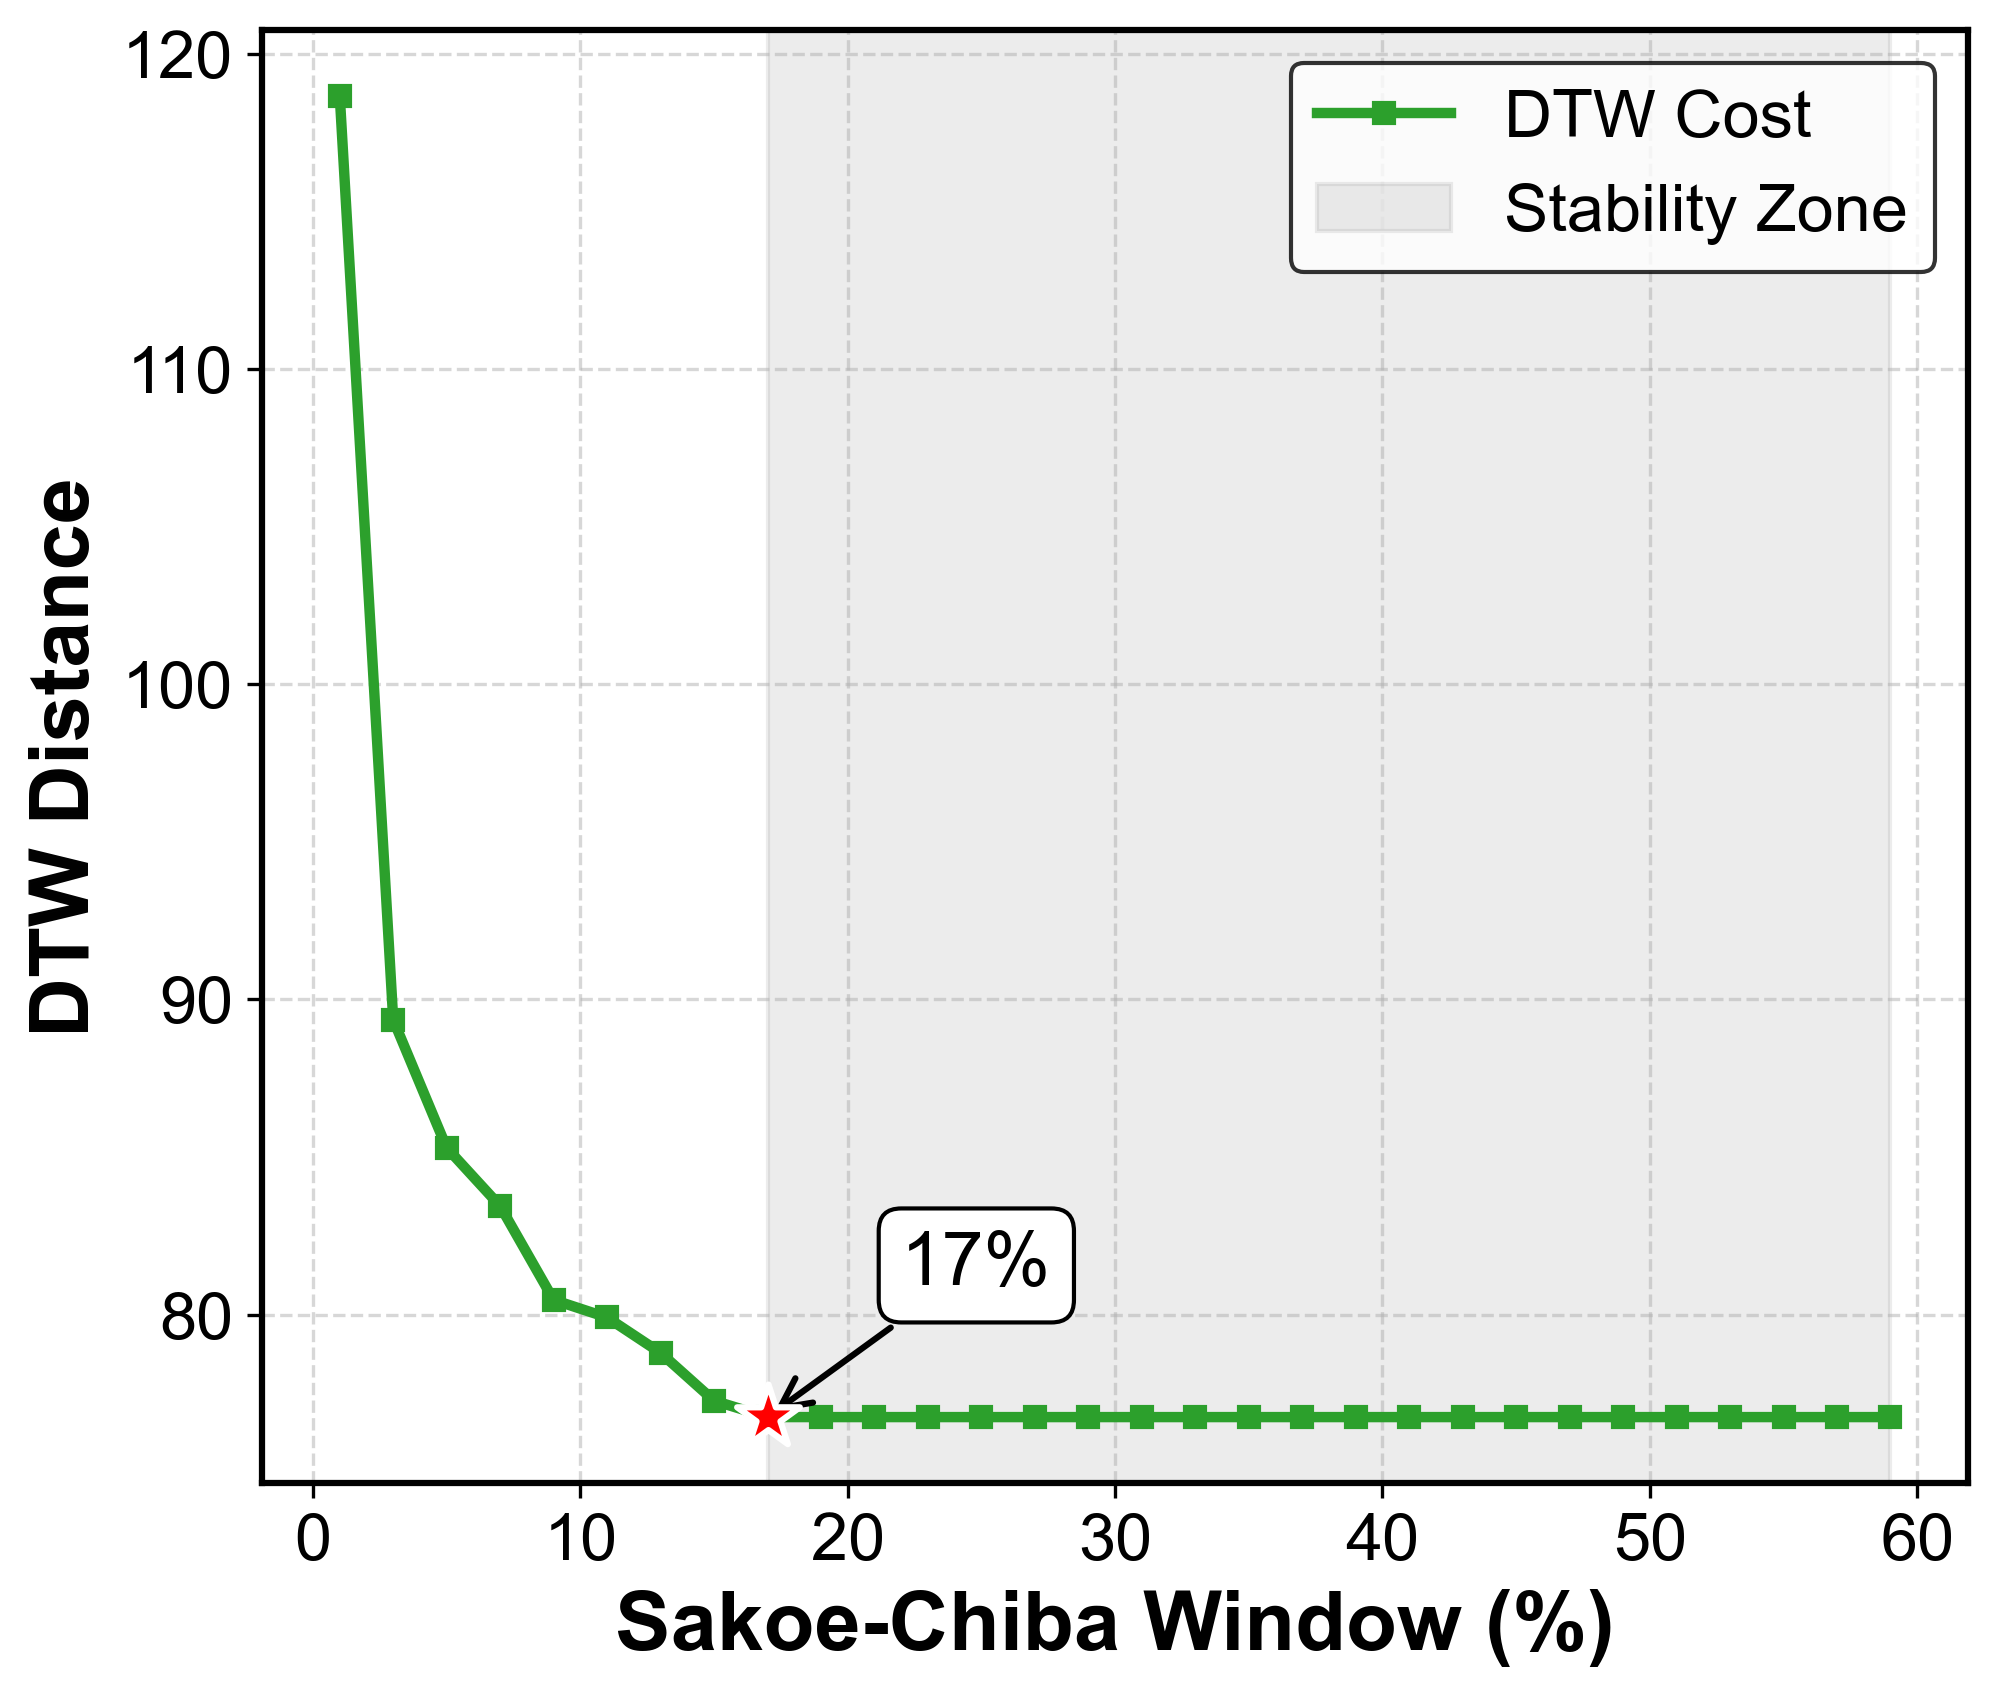

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- GLOBAL STYLE (Matches your reference) ---
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_well_optimization(percents, distances, well_pair, log_type):
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    
    percents_list = list(percents)
    dist_list = list(distances)
    min_dist = min(dist_list)
    opt_idx = dist_list.index(min_dist)
    opt_window = percents_list[opt_idx]
    
    # 1. Figure Setup (Matching the 7x6 size)
    fig, ax = plt.subplots(figsize=(7, 6))

    # 2. Plot Data - GREEN, Squares, Thinner lines
    ax.plot(percents_list, dist_list, color='#2ca02c', lw=2.5, 
            marker='s', ms=5, label='DTW Cost')
    
    # 3. Stability Shading
    ax.axvspan(opt_window, max(percents_list), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # 4. Mark Optimum Point (Red Star with white edge)
    ax.scatter(opt_window, min_dist, color='red', edgecolor='white', 
               linewidth=1.5, s=250, marker='*', zorder=20)

    # 5. Annotation (Scaled down and simplified)
    ax.annotate(f'{opt_window}%',
                xy=(opt_window, min_dist),
                xytext=(opt_window + 5, min_dist + (max(dist_list)-min_dist)*0.1),
                arrowprops=dict(arrowstyle='->', lw=1.5),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

    # 6. Labels (Simplified to match first plot)
    ax.set_xlabel("Sakoe-Chiba Window (%)")
    ax.set_ylabel("DTW Distance")

    # 7. Legend (No shadow, black frame)
    leg = ax.legend(loc='upper right', frameon=True)
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(1.0)

    # Grid and Spines
    ax.grid(True, linestyle='--', alpha=0.5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    plt.tight_layout()
    save_path = f"L_curve/{well_pair}_{log_type}_Lcurve_FINAL.jpg"
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

# --- CALL ---
nphi_range = np.arange(1, 61, 2)
# Ensure nphi_grid_results["J6A-J4"] is loaded in your notebook
plot_well_optimization(nphi_range, nphi_grid_results["J6A-J4"], "J6A-J4", "NPHI")

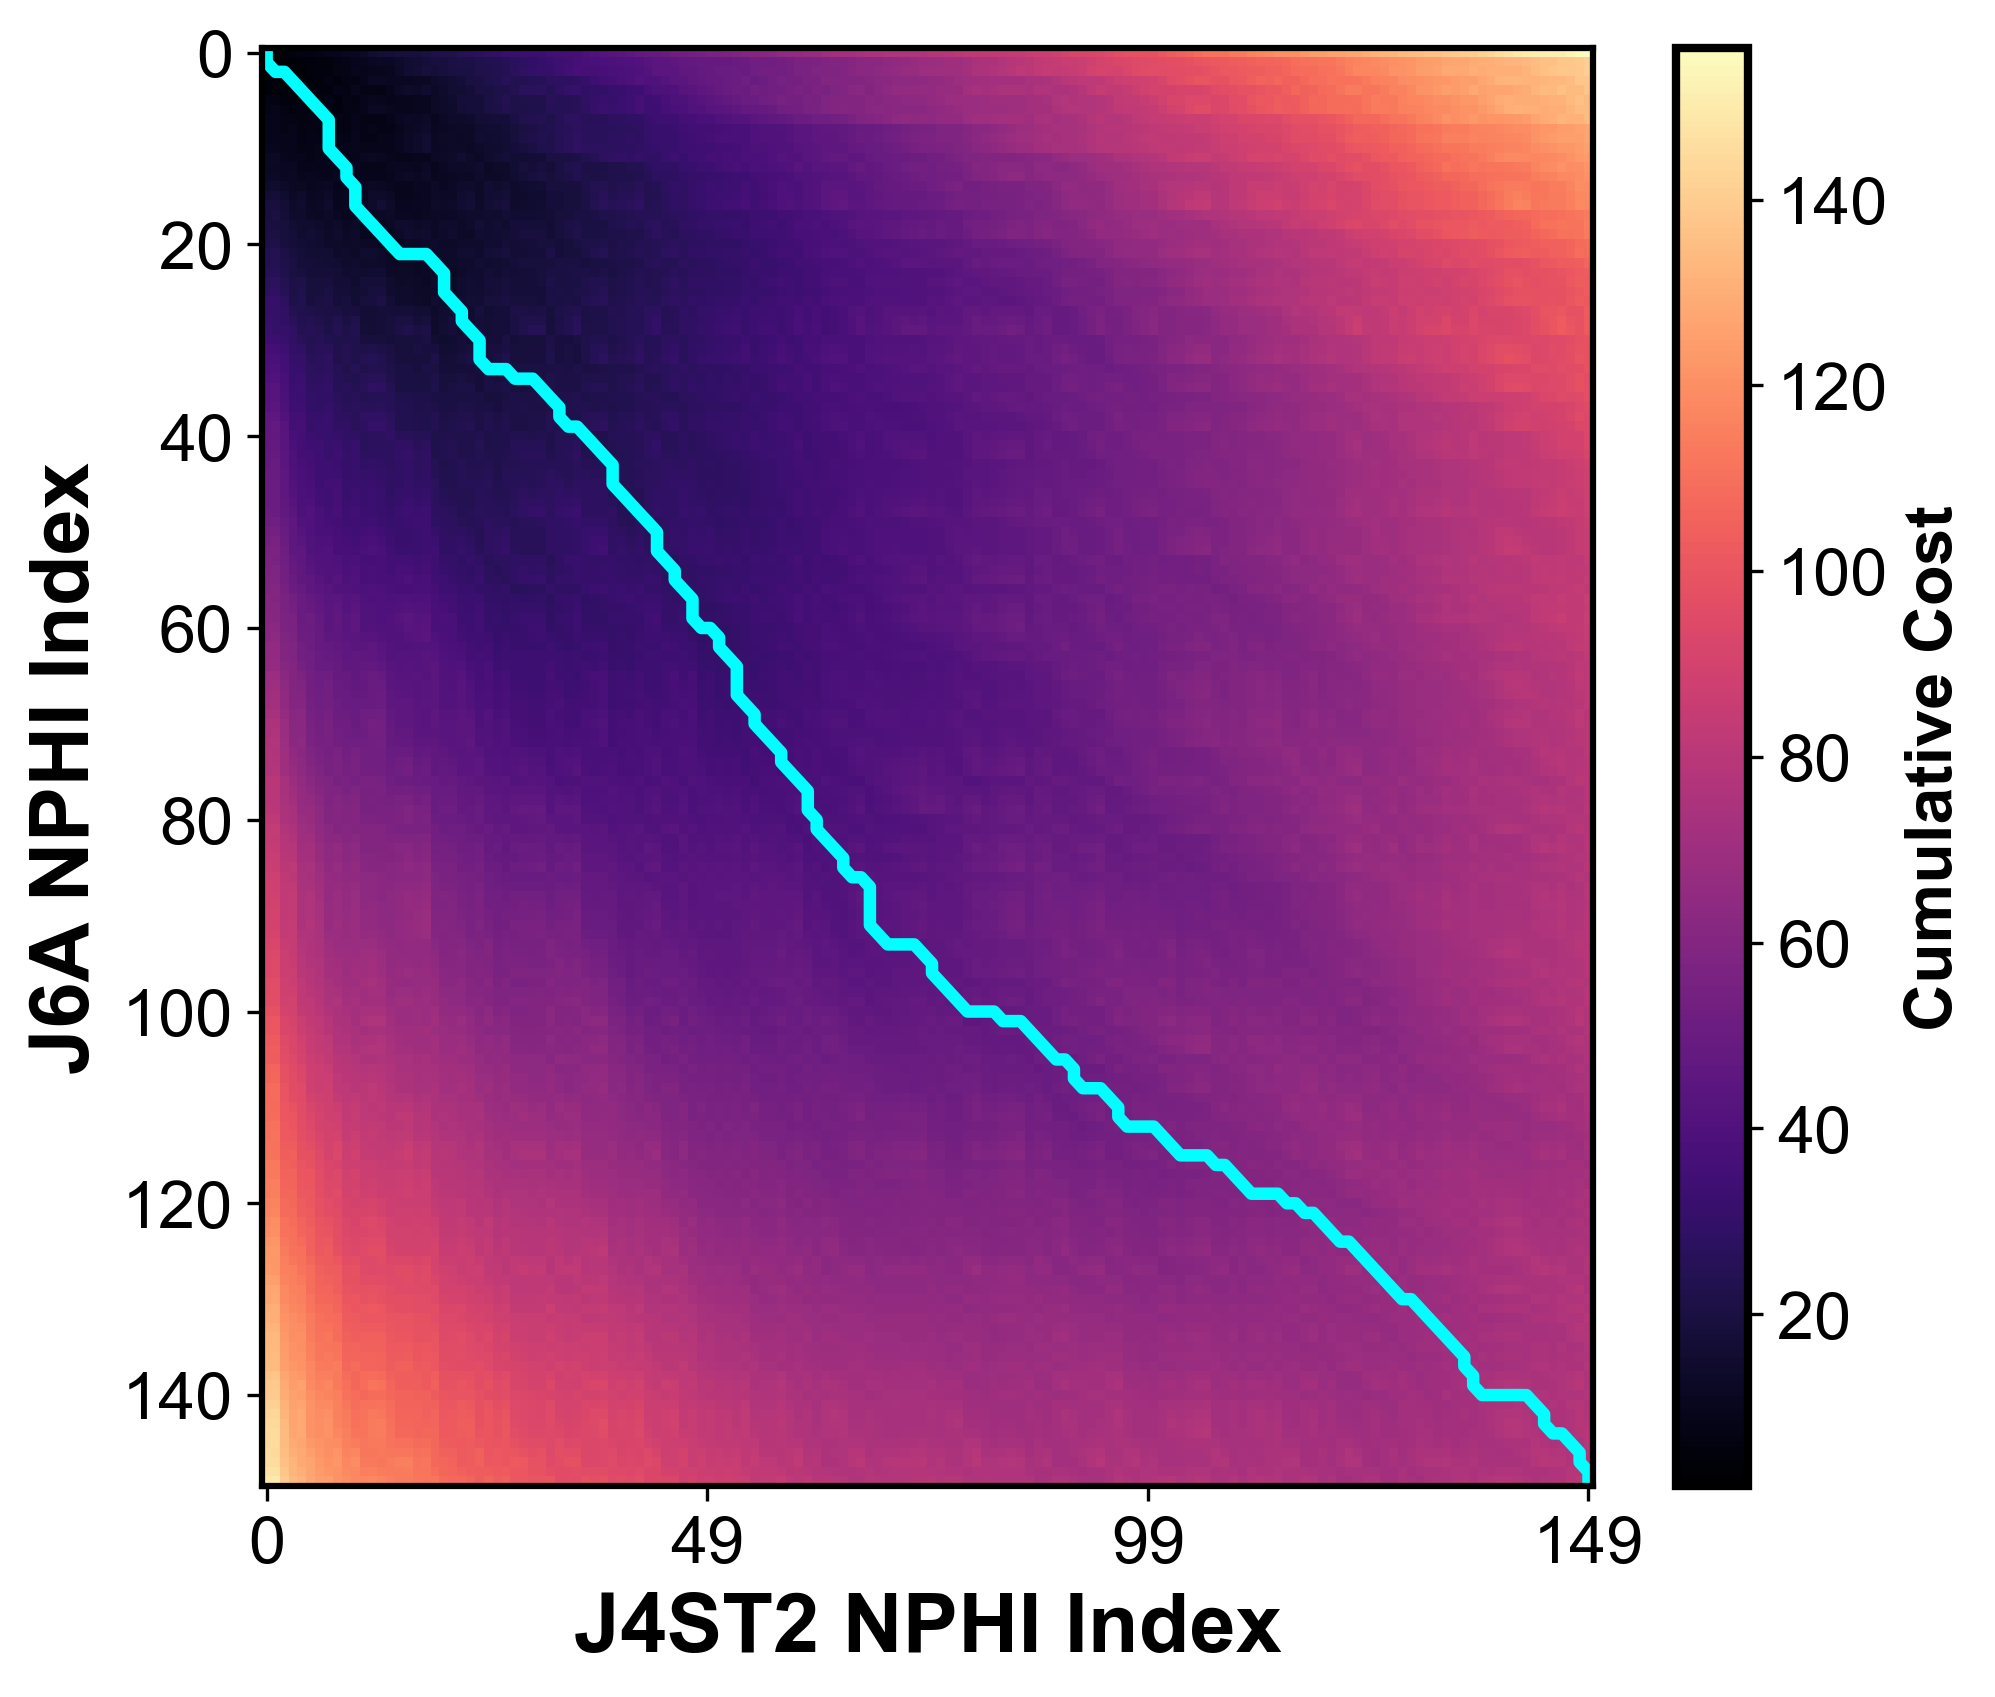

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# --- STYLE PARAMETERS (Matching Plot 1) ---
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_full_nphi_warping_J4_J6(df1, df2, label1="J4ST2", label2="J6A"):
    # 1. Standardize the NPHI logs (using column index 2 as per your first script)
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 2].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 2].values.reshape(-1,1)).flatten()
    n, m = len(s1), len(s2)
    
    # 2. Compute FULL DTW matrix (No Window)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],
                dtw_matrix[i, j-1],
                dtw_matrix[i-1, j-1]
            )
    
    # 3. Backtracking optimal path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        move = np.argmin(steps)
        if move == 0: i, j = i-1, j-1
        elif move == 1: i -= 1
        else: j -= 1
    path = np.array(path[::-1])

    # 4. VISUALIZATION (7x6 Figure to match Plot 1)
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # Slice to remove the infinite padding row/column
    matrix = dtw_matrix[1:, 1:]
    
    img = ax.imshow(
        matrix.T,
        origin='upper',
        cmap='magma',
        aspect='auto'
    )
    
    # 5. PLOT PATH (Cyan, Thick)
    ax.plot(path[:, 0], path[:, 1], color='cyan', linewidth=3)
    
    # 6. LABELS & TICKS
    ax.set_xlabel(f"{label1} NPHI Index")
    ax.set_ylabel(f"{label2} NPHI Index")
    
    # Add 4 clean x-ticks as requested
    xticks = np.linspace(0, n-1, 4)
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in xticks])

    # 7. COLORBAR
    cbar = plt.colorbar(img)
    cbar.set_label("Cumulative Cost", fontsize=16, fontweight='bold')

    # Border Styling
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')
    
    ax.grid(False)
    plt.tight_layout()

    # Save
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_NPHI_Full_Warping_FINAL.jpg"
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

# -------------------------------
# EXECUTION
# -------------------------------
plot_full_nphi_warping_J4_J6(df_j4, df_j6a)

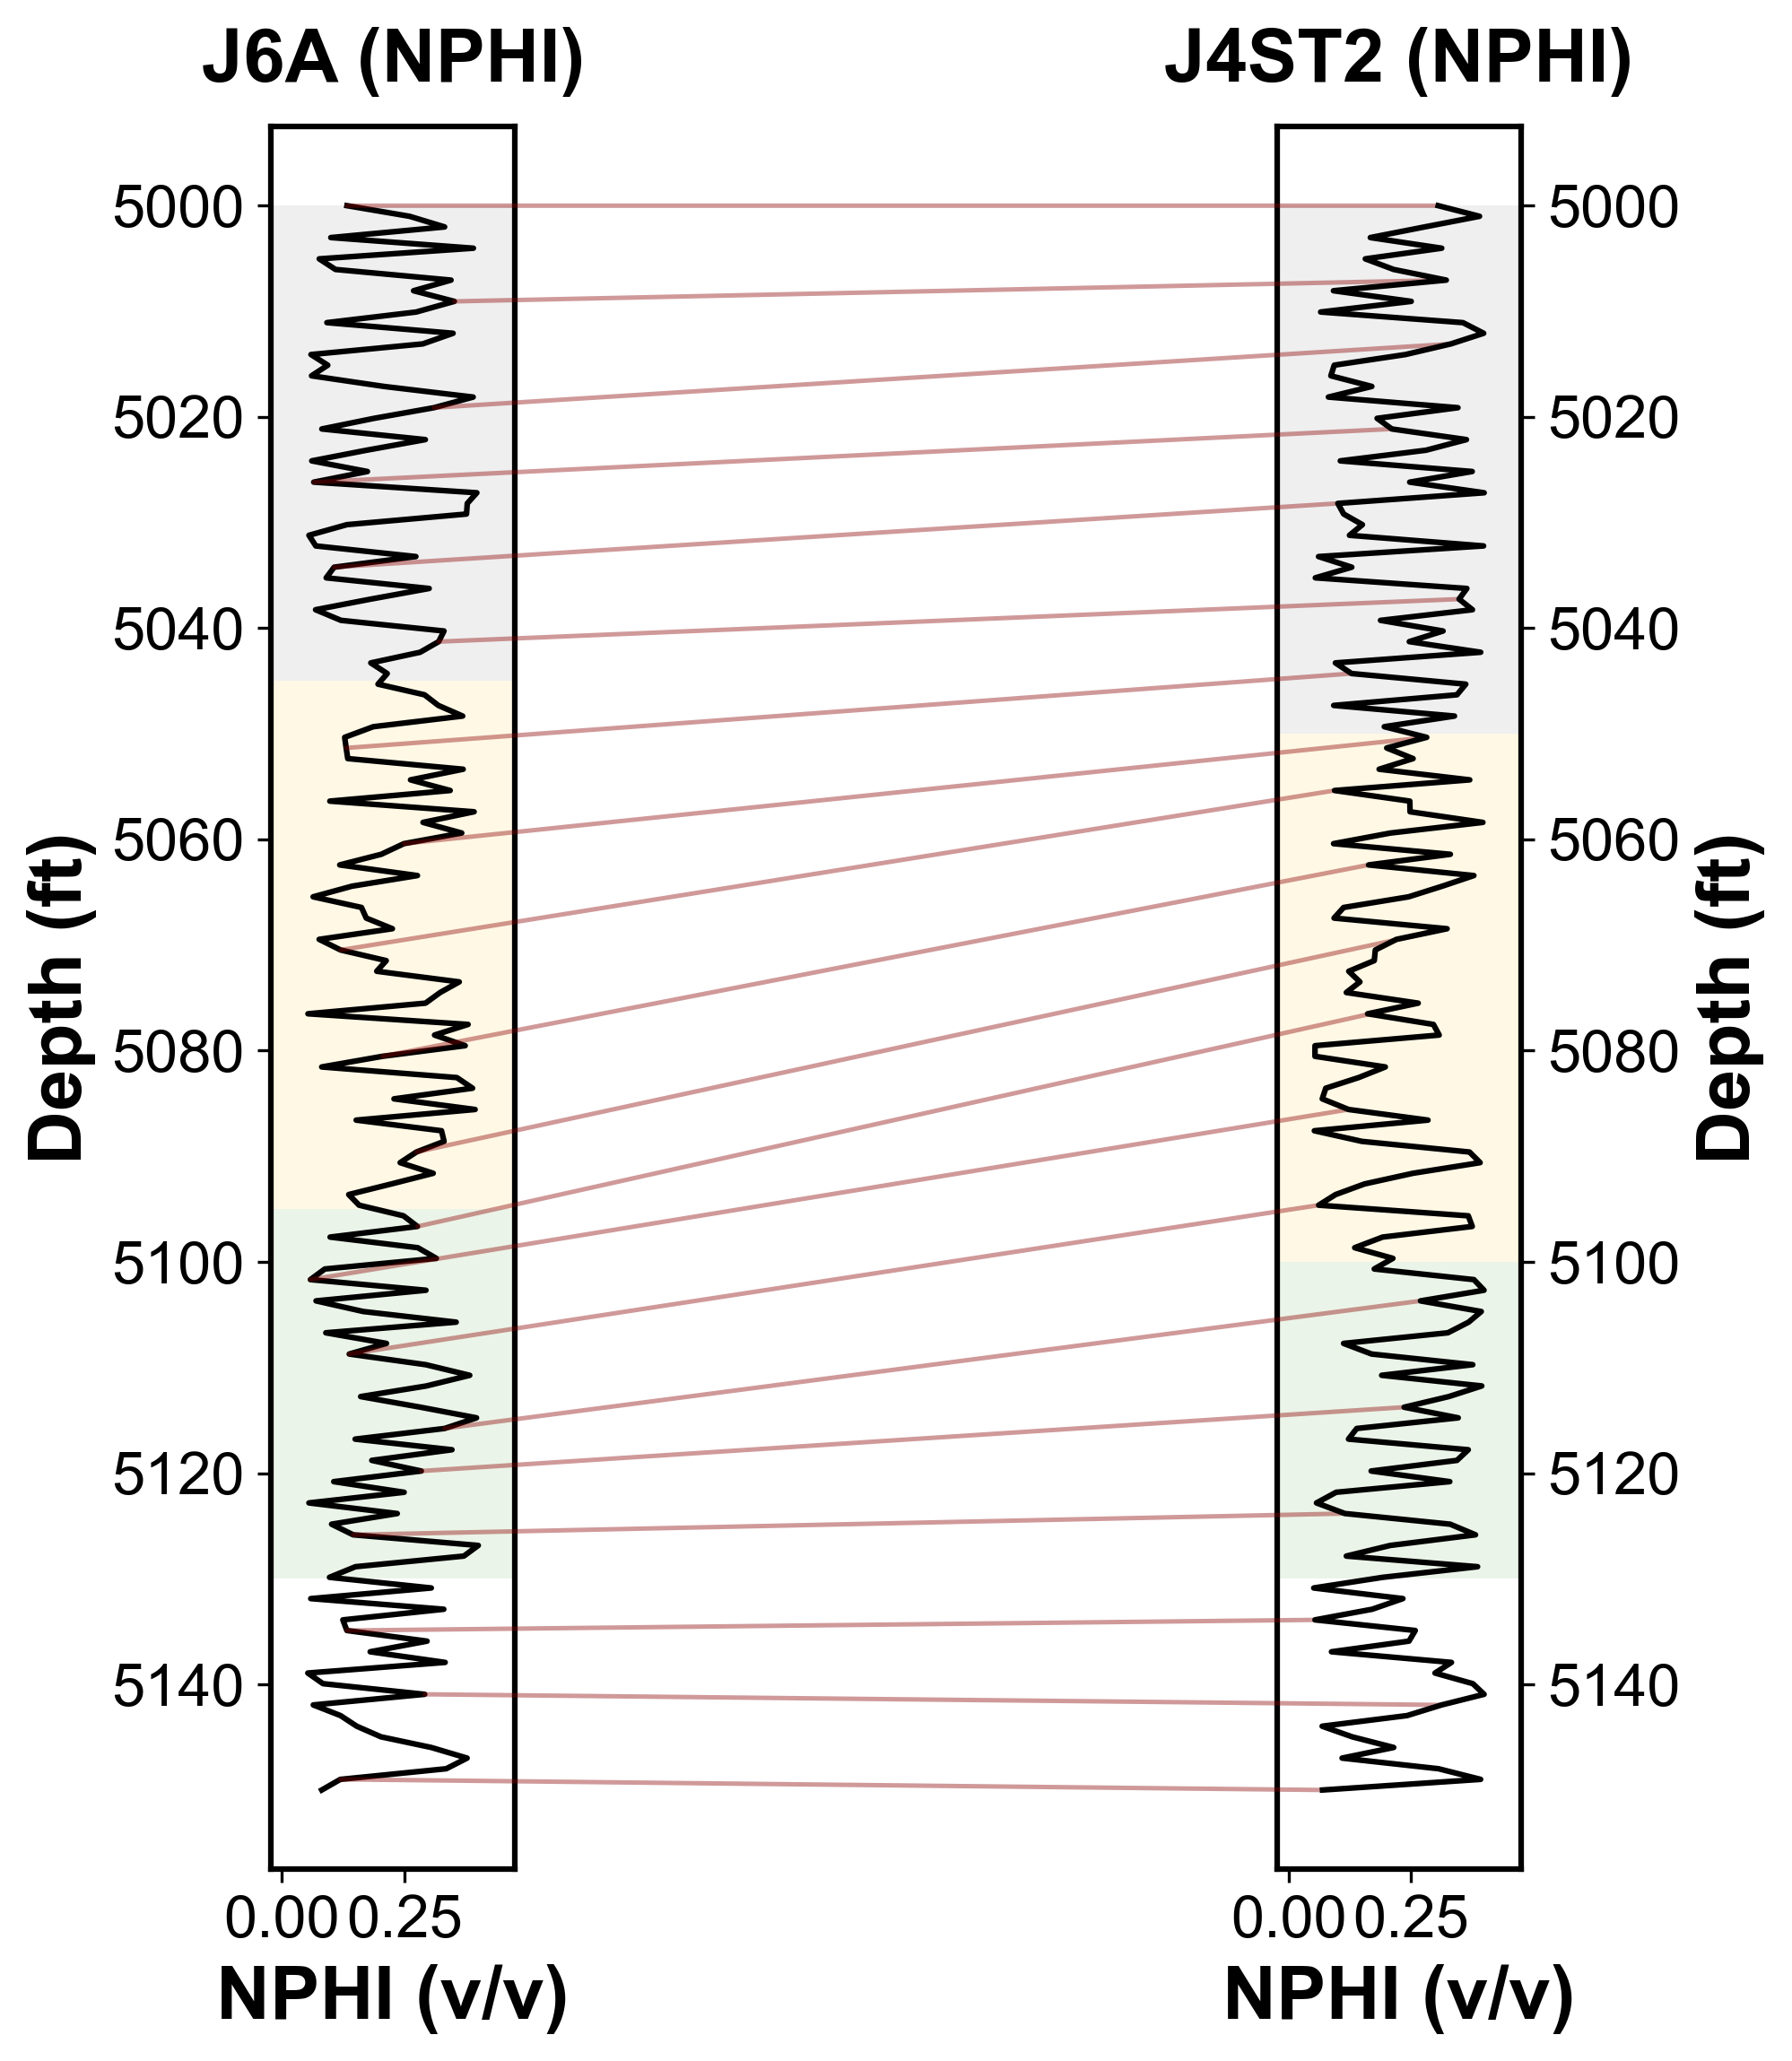

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import StandardScaler
import os

# --- STYLE FOR PUBLICATION (Matches Plot 1) ---
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_nphi_correlation_j6_j4(df1, df2, zones1, zones2, label1, label2, window_p):
    # 1. Standardize NPHI logs
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 2].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 2].values.reshape(-1,1)).flatten()
    
    # 2. Get the path
    path = dtw_with_path(s1, s2, window_p)
    
    # 3. Figure Setup (Matching the 7x8 aspect ratio of Plot 1)
    fig, axes = plt.subplots(1, 2, figsize=(7, 8)) 

    for i, (df, zones, name) in enumerate([(df1, zones1, label1), (df2, zones2, label2)]):
        ax = axes[i]
        depth = df.iloc[:, 0]
        nphi = df.iloc[:, 2]
        
        # Plot Log (Matching lw=1.5 from Plot 1)
        ax.plot(nphi, depth, color='black', lw=1.5, zorder=5)
        ax.invert_yaxis()
        
        # Labels and Titles
        ax.set_title(f"{name} (NPHI)", fontweight='bold', pad=12)
        ax.set_xlabel("NPHI (v/v)")
        ax.set_ylabel("Depth (ft)")

        if i == 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()
        
        # 4. Stratigraphic Shading (FIXED: Using facecolor to remove matplotlib warning)
        for _, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, facecolor=color, alpha=0.5, zorder=2)

        # 5. X-AXIS PADDING (The spacing fix)
        xmin, xmax = ax.get_xlim()
        pad = 0.15 * (xmax - xmin)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Border styling
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')

        # REMOVE GRID (to match Plot 1)
        ax.grid(False)

    # 6. Correlation Lines (Matching lw=1.2 and alpha=0.4)
    # --- FIX 2: Reduced step size from 120 to 10 for validation datasets ---
    line_density_step = 10 

    for idx in range(0, len(path), line_density_step): 
        idx1, idx2 = path[idx]
        y1, x1 = df1.iloc[idx1, 0], df1.iloc[idx1, 2]
        y2, x2 = df2.iloc[idx2, 0], df2.iloc[idx2, 2]

        con = ConnectionPatch(xyA=(x1, y1), xyB=(x2, y2), 
                              coordsA="data", coordsB="data",
                              axesA=axes[0], axesB=axes[1], 
                              color="darkred", alpha=0.4, lw=1.2, zorder=4)
        axes[1].add_artist(con)

    plt.tight_layout()

    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    save_name = f"L_curve/{label1}_{label2}_NPHI_Correlation_FINAL.jpg"
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()

# --- Execute ---
# --- FIX 3: Passed the dummy zone parameters to overlay your validation logs correctly ---
plot_nphi_correlation_j6_j4(df_j6a, df_j4, zones_j6a, zones_j4, "J6A", "J4ST2", 0.17)